# 🧠 Class 11.5 — LSTM Neural Networks for Time Series
### 301 – ML Techniques | Week 11

**Learning Goals:** Understand RNN/LSTM gate intuition, reshape data to 3D tensors, build LSTM in Keras, enable GPU, compare all forecasting methods.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.rcParams['figure.figsize'] = (13, 5)
print('✅ Ready')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

print(f'TF: {tf.__version__}')
print('GPU available:', len(tf.config.list_physical_devices("GPU")) > 0)

✅ Ready
TF: 2.21.0
GPU available: False


---
## Part 1 — Why LSTM?

**RNN** (Recurrent Neural Network): processes sequences — each step passes a hidden state to the next.
**Problem**: vanishing gradients over long sequences — can't remember events far in the past.

**LSTM** (Long Short-Term Memory): adds three gates:
- **Forget gate**: what to erase from memory
- **Input gate**: what new information to store
- **Output gate**: what to output

Result: can capture **long-range dependencies** in sequences.

Temperature series: 1095 days
Range: -8.6°C to 31.2°C


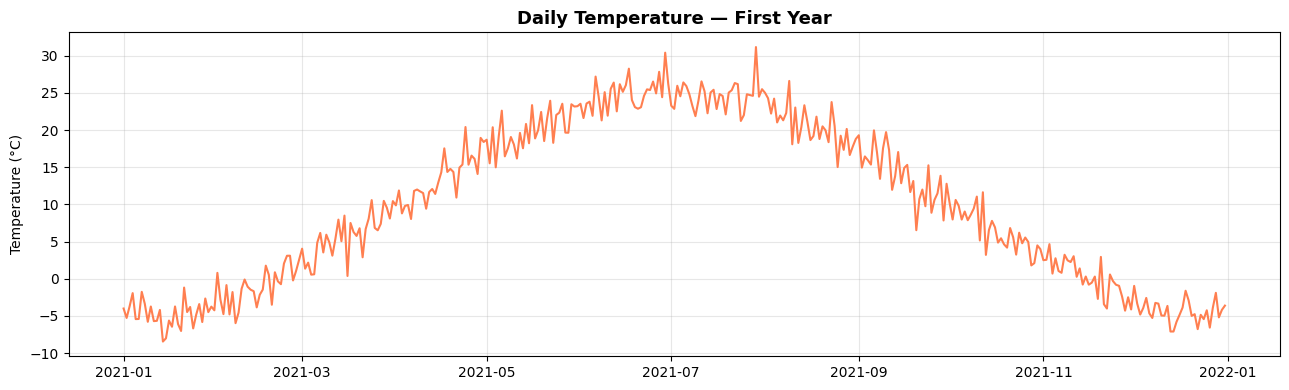

In [2]:
# Temperature forecasting (synthetic daily temperatures)
np.random.seed(42)
n = 365 * 3  # 3 years
dates = pd.date_range('2021-01-01', periods=n, freq='D')
annual = 15 * np.sin(2*np.pi*np.arange(n)/365 - np.pi/2) + 10
noise  = np.random.normal(0, 2, n)
temp   = pd.Series(annual + noise, index=dates, name='Temperature (C)')

print(f'Temperature series: {n} days')
print(f'Range: {temp.min():.1f}°C to {temp.max():.1f}°C')

plt.figure(figsize=(13, 4))
plt.plot(temp.index[:365], temp.values[:365], color='coral', linewidth=1.5)
plt.title('Daily Temperature — First Year', fontsize=13, fontweight='bold')
plt.ylabel('Temperature (°C)'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [3]:
# Scale to [0, 1] — LSTM is sensitive to scale
scaler = MinMaxScaler()
scaled = scaler.fit_transform(temp.values.reshape(-1, 1)).flatten()

# Chronological split
split_idx = int(len(scaled) * 0.8)
train_sc = scaled[:split_idx]
test_sc  = scaled[split_idx:]

# Create windowed sequences for LSTM
# X shape: (samples, timesteps, features)   ← 3D tensor required by LSTM
def create_sequences(data, window=30):
    """Turn 1D time series into (samples, timesteps, 1) for LSTM."""
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X)[..., np.newaxis], np.array(y)   # add feature dim

WINDOW = 30  # look back 30 days to predict the next
X_train_seq, y_train_seq = create_sequences(train_sc, WINDOW)
X_test_seq,  y_test_seq  = create_sequences(test_sc,  WINDOW)

print(f'X_train shape: {X_train_seq.shape}  (samples, timesteps, features)')
print(f'y_train shape: {y_train_seq.shape}')
print('⚠️  The 3D shape (batch, timesteps, features) is required by LSTM in Keras')

X_train shape: (846, 30, 1)  (samples, timesteps, features)
y_train shape: (846,)
⚠️  The 3D shape (batch, timesteps, features) is required by LSTM in Keras


In [4]:
# Build LSTM model
tf.random.set_seed(42)
lstm_model = keras.Sequential([
    layers.LSTM(50, input_shape=(WINDOW, 1)),
    layers.Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

from tensorflow.keras.callbacks import EarlyStopping
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=50, batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
    verbose=1
)
print(f'Trained for {len(history.history["loss"])} epochs')


/Users/tetsuya/.pyenv/versions/3.13.7/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0492 - mae: 0.1601 - val_loss: 0.0076 - val_mae: 0.0699
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0062 - mae: 0.0636 - val_loss: 0.0030 - val_mae: 0.0420
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0039 - mae: 0.0507 - val_loss: 0.0037 - val_mae: 0.0463
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 - mae: 0.0481 - val_loss: 0.0042 - val_mae: 0.0501
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0035 - mae: 0.0477 - val_loss: 0.0042 - val_mae: 0.0496
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0034 - mae: 0.0472 - val_loss: 0.0039 - val_mae: 0.0478
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0033 - mae: 0.0466 - val_loss: 0.0036 - val_mae: 0.0466
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0033 - mae: 0.0460 - val_loss: 0.0034 - val_mae: 0.0458
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0032 - mae

LSTM MAE: 1.65°C


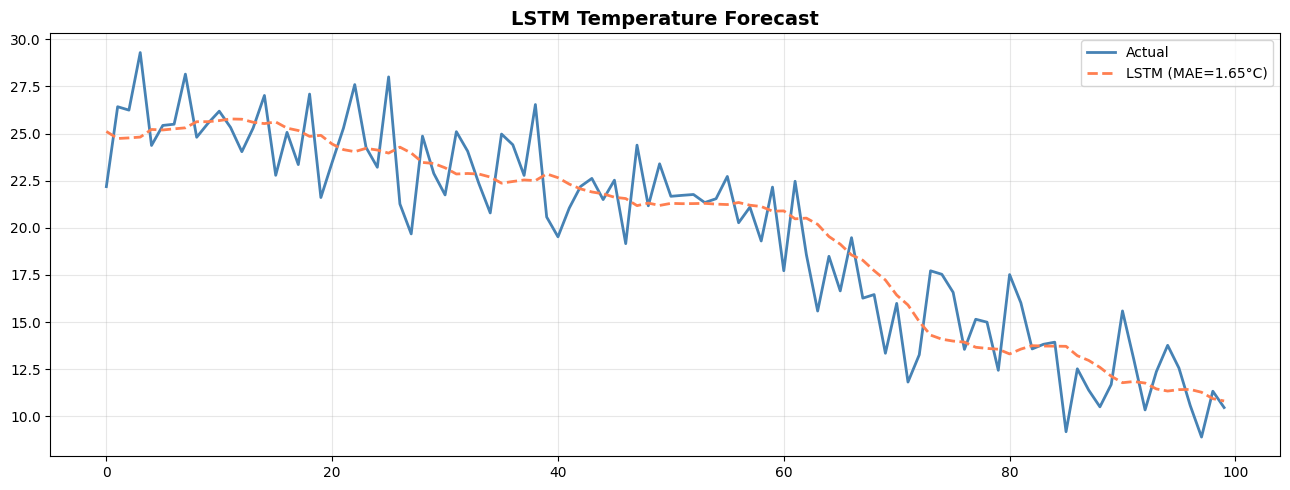

In [5]:
# Evaluate and inverse-transform
y_pred_sc = lstm_model.predict(X_test_seq, verbose=0).flatten()
y_pred    = scaler.inverse_transform(y_pred_sc.reshape(-1,1)).flatten()
y_true    = scaler.inverse_transform(y_test_seq.reshape(-1,1)).flatten()

mae_lstm = mean_absolute_error(y_true, y_pred)
print(f'LSTM MAE: {mae_lstm:.2f}°C')

# Plot
n_show = 100
plt.figure(figsize=(13, 5))
plt.plot(range(n_show), y_true[:n_show],  color='steelblue', linewidth=2, label='Actual')
plt.plot(range(n_show), y_pred[:n_show],  color='coral',     linewidth=2, linestyle='--',
         label=f'LSTM (MAE={mae_lstm:.2f}°C)')
plt.title('LSTM Temperature Forecast', fontsize=14, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## ✅ Complete!

- **LSTM**: learns long-range dependencies — better than ARIMA for complex patterns
- **3D input** (samples, timesteps, features) — the key reshape step
- **Scaling**: LSTM needs data in [0,1] or [-1,1] — always use MinMaxScaler or StandardScaler
- **Window size**: how many past timesteps to use — tune this as a hyperparameter